In [ ]:
import os
os.chdir(r"C:\Users\paran\OneDrive\python_projects\supply-chain-app")
print(f"Working directory: {os.getcwd()}")


<div style="background:linear-gradient(135deg,#1a2a4a 0%,#2d4a7a 100%);padding:40px;border-radius:12px;margin-bottom:30px;">
  <h1 style="color:white;font-size:2.2em;margin:0 0 10px 0;">⚙️ Step 2 — Feature Engineering</h1>
  <p style="color:#a8c4e0;font-size:1.1em;margin:0;">Supply Chain Planning System · Manufacturing Sector</p>
  <div style="margin-top:20px;display:flex;gap:15px;flex-wrap:wrap;">
    <span style="background:rgba(255,255,255,0.15);color:white;padding:5px 14px;border-radius:20px;font-size:.85em;">🔗 Merge 6 datasets</span>
    <span style="background:rgba(255,255,255,0.15);color:white;padding:5px 14px;border-radius:20px;font-size:.85em;">⏳ Lag features</span>
    <span style="background:rgba(255,255,255,0.15);color:white;padding:5px 14px;border-radius:20px;font-size:.85em;">📊 Rolling statistics</span>
    <span style="background:rgba(255,255,255,0.15);color:white;padding:5px 14px;border-radius:20px;font-size:.85em;">🔢 Encoding</span>
    <span style="background:rgba(255,255,255,0.15);color:white;padding:5px 14px;border-radius:20px;font-size:.85em;">✅ ML-ready dataset</span>
  </div>
</div>



<div style="background:#f0f7ff;border-left:5px solid #2d6cdf;padding:20px 25px;border-radius:0 8px 8px 0;margin-bottom:25px;">
  <h2 style="color:#1a2a4a;margin-top:0;">🎯 Purpose of this notebook</h2>
  <p style="color:#333;line-height:1.7;">XGBoost requires a <strong>single flat table</strong> where every row is one observation and every column is a numeric feature. Right now we have 6 separate CSVs with text columns, different granularities, and no temporal features. This notebook transforms all of that into one clean, model-ready dataset.</p>
  <div style="display:grid;grid-template-columns:1fr 1fr;gap:15px;margin-top:15px;">
    <div style="background:white;padding:15px;border-radius:8px;border:1px solid #dee2e6;">
      <strong style="color:#e84a5f;">❌ What XGBoost cannot handle</strong>
      <ul style="color:#555;margin-top:8px;line-height:2;font-size:.9em;">
        <li>Multiple separate tables</li>
        <li>Text / categorical strings</li>
        <li>Missing temporal context</li>
        <li>Raw dates as features</li>
      </ul>
    </div>
    <div style="background:white;padding:15px;border-radius:8px;border:1px solid #dee2e6;">
      <strong style="color:#2ecc71;">✅ What we will produce</strong>
      <ul style="color:#555;margin-top:8px;line-height:2;font-size:.9em;">
        <li>One flat table (~1,040 rows)</li>
        <li>All columns numeric</li>
        <li>Lag & rolling features</li>
        <li>Calendar features encoded</li>
      </ul>
    </div>
  </div>
</div>



<div style="background:#1a2a4a;padding:12px 20px;border-radius:8px;margin:20px 0 5px 0;">
  <h2 style="color:white;margin:0;font-size:1.2em;">🔧 Section 0 — Setup & load raw data</h2>
</div>



<div style="background:#f8f9fa;border:1px solid #dee2e6;padding:18px 22px;border-radius:8px;margin-bottom:10px;">
  <h4 style="color:#1a2a4a;margin-top:0;">📖 What this section does</h4>
  <p style="color:#444;line-height:1.7;">Loads the 6 CSVs generated in Notebook 01 and performs a quick sanity check to make sure all files are present and have the expected number of rows before we start transforming anything.</p>
  <p style="color:#666;font-size:.9em;margin-bottom:0;">⚠️ <strong>Important:</strong> make sure you have already run Notebook 01 and that the <code>data/raw/</code> folder exists with all 6 CSV files.</p>
</div>


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
from IPython.display import display, HTML

warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
RAW_DIR       = "data/raw"
PROCESSED_DIR = "data/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

# ── Load all 6 datasets ───────────────────────────────────────────────────────
# parse_dates ensures the 'week' column is loaded as datetime, not a plain string.
# This is critical for sorting and time-based operations later.
df_products   = pd.read_csv(f"{RAW_DIR}/products.csv")
df_orders     = pd.read_csv(f"{RAW_DIR}/orders.csv",     parse_dates=['week'])
df_production = pd.read_csv(f"{RAW_DIR}/production.csv", parse_dates=['week'])
df_suppliers  = pd.read_csv(f"{RAW_DIR}/suppliers.csv",  parse_dates=['week'])
df_externals  = pd.read_csv(f"{RAW_DIR}/externals.csv",  parse_dates=['week'])
df_customers  = pd.read_csv(f"{RAW_DIR}/customers.csv",  parse_dates=['week'])

# ── Sanity check ──────────────────────────────────────────────────────────────
print("✅ All datasets loaded\n")
datasets = {
    'products':   df_products,
    'orders':     df_orders,
    'production': df_production,
    'suppliers':  df_suppliers,
    'externals':  df_externals,
    'customers':  df_customers,
}
for name, df in datasets.items():
    print(f"   {name:12s} → {len(df):>6,} rows · {df.shape[1]:>2} cols")


✅ All datasets loaded

   products     →     10 rows ·  9 cols
   orders       →  1,040 rows ·  7 cols
   production   →  1,040 rows ·  8 cols
   suppliers    →    312 rows ·  8 cols
   externals    →    104 rows ·  9 cols
   customers    →    520 rows ·  8 cols



<div style="background:#1a2a4a;padding:12px 20px;border-radius:8px;margin:20px 0 5px 0;">
  <h2 style="color:white;margin:0;font-size:1.2em;">🔗 Section 1 — Merge all datasets</h2>
</div>



<div style="background:#f8f9fa;border:1px solid #dee2e6;padding:18px 22px;border-radius:8px;margin-bottom:10px;">
  <h4 style="color:#1a2a4a;margin-top:0;">📖 What this section does</h4>
  <p style="color:#444;line-height:1.7;">Joins all 6 tables into one master DataFrame. The key concept is <strong>granularity</strong> — each dataset has a different level of detail, and we need to decide how to combine them:</p>
  <table style="width:100%;font-size:.9em;border-collapse:collapse;margin-top:10px;">
    <tr style="background:#2d6cdf;color:white;">
      <th style="padding:8px 12px;text-align:left;">Dataset</th>
      <th style="padding:8px 12px;text-align:left;">Granularity</th>
      <th style="padding:8px 12px;text-align:left;">Join key</th>
      <th style="padding:8px 12px;text-align:left;">Strategy</th>
    </tr>
    <tr style="background:white;"><td style="padding:8px 12px;">orders</td><td style="padding:8px 12px;">product × week</td><td style="padding:8px 12px;">product_id + week_index</td><td style="padding:8px 12px;">Base table</td></tr>
    <tr style="background:#f0f7ff;"><td style="padding:8px 12px;">production</td><td style="padding:8px 12px;">product × week</td><td style="padding:8px 12px;">product_id + week_index</td><td style="padding:8px 12px;">Direct join</td></tr>
    <tr style="background:white;"><td style="padding:8px 12px;">externals</td><td style="padding:8px 12px;">week only</td><td style="padding:8px 12px;">week_index</td><td style="padding:8px 12px;">Direct join (broadcasts to all products)</td></tr>
    <tr style="background:#f0f7ff;"><td style="padding:8px 12px;">suppliers</td><td style="padding:8px 12px;">supplier × week</td><td style="padding:8px 12px;">supplier_id + week_index</td><td style="padding:8px 12px;">Join via product→supplier mapping</td></tr>
    <tr style="background:white;"><td style="padding:8px 12px;">customers</td><td style="padding:8px 12px;">customer × week</td><td style="padding:8px 12px;">week_index</td><td style="padding:8px 12px;">Aggregate to weekly level first</td></tr>
    <tr style="background:#f0f7ff;"><td style="padding:8px 12px;">products</td><td style="padding:8px 12px;">product only</td><td style="padding:8px 12px;">product_id</td><td style="padding:8px 12px;">Direct join (broadcasts to all weeks)</td></tr>
  </table>
</div>


In [2]:

# ── Step 1: Start with orders as the base table ───────────────────────────────
# orders has the right granularity (product × week) and contains our target variable.
# Every other table will be joined onto this.
df = df_orders.copy()
print(f"Base table (orders):  {df.shape}")

# ── Step 2: Join production (same granularity — product × week) ───────────────
# We only bring in the columns we need, dropping duplicates like 'week'.
prod_cols = ['product_id','week_index','capacity_hours','maintenance_hours',
             'produced_units','scrap_units','utilisation_pct']
df = df.merge(df_production[prod_cols], on=['product_id','week_index'], how='left')
print(f"After + production:   {df.shape}")

# ── Step 3: Join externals (week-level → broadcasts to all products) ──────────
# Since externals has one row per week, joining on week_index means every product
# in that week gets the same PMI, energy price, etc. This is correct behaviour.
ext_cols = ['week_index','pmi','energy_price_kwh','exchange_rate_eur_usd',
            'is_holiday','plant_shutdown','week_of_year','quarter']
df = df.merge(df_externals[ext_cols], on='week_index', how='left')
print(f"After + externals:    {df.shape}")

# ── Step 4: Join product catalogue (product-level → broadcasts to all weeks) ──
# Similar to externals: one row per product, joins to all 104 weeks for that product.
prod_cat_cols = ['product_id','category','supplier_id','cycle_time_h',
                 'defect_rate_pct','base_demand','sale_price_eur','trend_weekly']
df = df.merge(df_products[prod_cat_cols], on='product_id', how='left')
print(f"After + products:     {df.shape}")

# ── Step 5: Join supplier data ────────────────────────────────────────────────
# Each product links to a supplier via supplier_id (from the product catalogue).
# We join supplier weekly data using both supplier_id AND week_index.
sup_cols = ['supplier_id','week_index','lead_time_real_d','reliability_pct','raw_material_price']
df = df.merge(df_suppliers[sup_cols], on=['supplier_id','week_index'], how='left')
print(f"After + suppliers:    {df.shape}")

# ── Step 6: Aggregate customers to weekly level then join ─────────────────────
# Customers table has 5 rows per week (one per customer).
# We need to collapse this to 1 row per week before joining.
# Strategy:
#   framework_contract_units → sum (total committed demand across all customers)
#   has_promotion → max (1 if ANY customer has a promotion that week)
#   has_launch    → max (1 if ANY customer has a launch that week)
cust_agg = (df_customers
            .groupby('week_index')
            .agg(
                total_contract_units=('framework_contract_units', 'sum'),
                any_promotion=('has_promotion', 'max'),
                any_launch=('has_launch', 'max'),
                n_active_sectors=('sector', 'nunique')   # diversity of active customers
            )
            .reset_index())
df = df.merge(cust_agg, on='week_index', how='left')
print(f"After + customers:    {df.shape}")

# ── Sort by product and week (critical for lag features later) ────────────────
df = df.sort_values(['product_id','week_index']).reset_index(drop=True)

print(f"\n✅ Master table ready: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"   Products: {df['product_id'].nunique()} · Weeks: {df['week_index'].nunique()}")


Base table (orders):  (1040, 7)
After + production:   (1040, 12)
After + externals:    (1040, 19)
After + products:     (1040, 26)
After + suppliers:    (1040, 29)
After + customers:    (1040, 33)

✅ Master table ready: 1040 rows × 33 columns
   Products: 10 · Weeks: 104



<div style="background:#1a2a4a;padding:12px 20px;border-radius:8px;margin:20px 0 5px 0;">
  <h2 style="color:white;margin:0;font-size:1.2em;">⏳ Section 2 — Lag features</h2>
</div>



<div style="background:#f8f9fa;border:1px solid #dee2e6;padding:18px 22px;border-radius:8px;margin-bottom:10px;">
  <h4 style="color:#1a2a4a;margin-top:0;">📖 What this section does</h4>
  <p style="color:#444;line-height:1.7;">Creates <strong>lag features</strong> — copies of past values of the target variable shifted forward in time. This is how we give XGBoost "memory": without lags, the model has no idea what happened in previous weeks.</p>
  <div style="background:#1e1e1e;color:#a8ff78;padding:15px 20px;border-radius:8px;font-family:monospace;font-size:.88em;line-height:1.9;margin:12px 0;">
    week 50: ordered_qty=215  lag_1=200  lag_2=190  lag_4=185  lag_52=208<br>
    week 51: ordered_qty=???  lag_1=215  lag_2=200  lag_4=190  lag_52=195<br>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↑ this is what<br>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;the model sees
  </div>
  <table style="width:100%;font-size:.9em;border-collapse:collapse;margin-top:10px;">
    <tr style="background:#2d6cdf;color:white;">
      <th style="padding:8px 12px;">Feature</th><th style="padding:8px 12px;">Lag</th><th style="padding:8px 12px;">Captures</th>
    </tr>
    <tr style="background:white;"><td style="padding:8px 12px;"><code>ordered_qty_lag_1</code></td><td style="padding:8px 12px;">1 week</td><td style="padding:8px 12px;">Immediate momentum — last week's demand</td></tr>
    <tr style="background:#f0f7ff;"><td style="padding:8px 12px;"><code>ordered_qty_lag_2</code></td><td style="padding:8px 12px;">2 weeks</td><td style="padding:8px 12px;">Short-term trend direction</td></tr>
    <tr style="background:white;"><td style="padding:8px 12px;"><code>ordered_qty_lag_4</code></td><td style="padding:8px 12px;">4 weeks (~1 month)</td><td style="padding:8px 12px;">Monthly demand level</td></tr>
    <tr style="background:#f0f7ff;"><td style="padding:8px 12px;"><code>ordered_qty_lag_8</code></td><td style="padding:8px 12px;">8 weeks (~2 months)</td><td style="padding:8px 12px;">Medium-term trend</td></tr>
    <tr style="background:white;"><td style="padding:8px 12px;"><code>ordered_qty_lag_13</code></td><td style="padding:8px 12px;">13 weeks (~1 quarter)</td><td style="padding:8px 12px;">Quarterly pattern</td></tr>
    <tr style="background:#f0f7ff;"><td style="padding:8px 12px;"><code>ordered_qty_lag_26</code></td><td style="padding:8px 12px;">26 weeks (~half year)</td><td style="padding:8px 12px;">Semi-annual seasonality</td></tr>
    <tr style="background:white;"><td style="padding:8px 12px;"><code>ordered_qty_lag_52</code></td><td style="padding:8px 12px;">52 weeks (1 year)</td><td style="padding:8px 12px;">Same week last year — strongest seasonal signal</td></tr>
  </table>
  <p style="color:#666;font-size:.9em;margin-top:12px;margin-bottom:0;">⚠️ <strong>Key point:</strong> lags are always computed <em>per product</em> using <code>groupby('product_id')</code>. Without this, the lag of product 1 week 5 would be the demand of product 1 week 4 — but if they're sorted incorrectly, you'd accidentally leak product 2's data into product 1.</p>
</div>


In [3]:

# ── Lag features for ordered_qty (the target variable) ───────────────────────
# We create lags at multiple time horizons to capture different patterns.
# groupby('product_id') ensures lags are computed independently per product.
# shift(n) moves the column down by n rows within each product group.

LAG_WEEKS = [1, 2, 4, 8, 13, 26, 52]

for lag in LAG_WEEKS:
    col_name = f'ordered_qty_lag_{lag}'
    # shift(lag) within each product group: row i gets the value from row i-lag
    df[col_name] = df.groupby('product_id')['ordered_qty'].shift(lag)

# ── Lag features for backlog (leading indicator of future demand pressure) ────
for lag in [1, 2, 4]:
    df[f'backlog_lag_{lag}'] = df.groupby('product_id')['backlog'].shift(lag)

# ── Lag features for production variables ─────────────────────────────────────
# These help the model understand recent supply-side constraints.
for lag in [1, 2]:
    df[f'utilisation_pct_lag_{lag}']  = df.groupby('product_id')['utilisation_pct'].shift(lag)
    df[f'scrap_units_lag_{lag}']      = df.groupby('product_id')['scrap_units'].shift(lag)
    df[f'capacity_hours_lag_{lag}']   = df.groupby('product_id')['capacity_hours'].shift(lag)

# ── Lag features for supplier variables ───────────────────────────────────────
# Lead time last week tells us if there's an ongoing supply disruption.
for lag in [1, 2]:
    df[f'lead_time_lag_{lag}']        = df.groupby('product_id')['lead_time_real_d'].shift(lag)
    df[f'reliability_pct_lag_{lag}']  = df.groupby('product_id')['reliability_pct'].shift(lag)

# ── Count how many lag features we created ────────────────────────────────────
lag_cols = [c for c in df.columns if '_lag_' in c]
print(f"✅ Lag features created: {len(lag_cols)}")
for col in lag_cols:
    null_pct = df[col].isnull().mean() * 100
    print(f"   {col:35s}  nulls: {null_pct:.0f}%")


✅ Lag features created: 20
   ordered_qty_lag_1                    nulls: 1%
   ordered_qty_lag_2                    nulls: 2%
   ordered_qty_lag_4                    nulls: 4%
   ordered_qty_lag_8                    nulls: 8%
   ordered_qty_lag_13                   nulls: 12%
   ordered_qty_lag_26                   nulls: 25%
   ordered_qty_lag_52                   nulls: 50%
   backlog_lag_1                        nulls: 1%
   backlog_lag_2                        nulls: 2%
   backlog_lag_4                        nulls: 4%
   utilisation_pct_lag_1                nulls: 1%
   scrap_units_lag_1                    nulls: 1%
   capacity_hours_lag_1                 nulls: 1%
   utilisation_pct_lag_2                nulls: 2%
   scrap_units_lag_2                    nulls: 2%
   capacity_hours_lag_2                 nulls: 2%
   lead_time_lag_1                      nulls: 1%
   reliability_pct_lag_1                nulls: 1%
   lead_time_lag_2                      nulls: 2%
   reliability_pct_l


<div style="background:#fff3cd;border:1px solid #ffc107;padding:15px 20px;border-radius:8px;margin:10px 0;">
  <h4 style="color:#1a2a4a;margin-top:0;">⚠️ About NaN values in lag features</h4>
  <p style="color:#444;line-height:1.7;margin-bottom:0;">You will see that <code>lag_52</code> has ~50% null values — this is expected and correct. The first 52 weeks of each product have no "same week last year" data. We <strong>do not fill these with zeros or means</strong> — that would introduce false information. Instead, we will drop rows with nulls at the end of this notebook, after all features are created. This means our training set will start from week 52 onward (still 52 weeks of usable data per product).</p>
</div>



<div style="background:#1a2a4a;padding:12px 20px;border-radius:8px;margin:20px 0 5px 0;">
  <h2 style="color:white;margin:0;font-size:1.2em;">📊 Section 3 — Rolling statistics</h2>
</div>



<div style="background:#f8f9fa;border:1px solid #dee2e6;padding:18px 22px;border-radius:8px;margin-bottom:10px;">
  <h4 style="color:#1a2a4a;margin-top:0;">📖 What this section does</h4>
  <p style="color:#444;line-height:1.7;">Creates <strong>rolling window statistics</strong> — aggregations computed over a sliding window of past weeks. While lags give the model a specific past value, rolling stats summarise a period of past behaviour.</p>
  <table style="width:100%;font-size:.9em;border-collapse:collapse;margin-top:10px;">
    <tr style="background:#2d6cdf;color:white;">
      <th style="padding:8px 12px;">Statistic</th><th style="padding:8px 12px;">Window</th><th style="padding:8px 12px;">What it captures</th>
    </tr>
    <tr style="background:white;"><td style="padding:8px 12px;"><code>rolling_mean</code></td><td style="padding:8px 12px;">4 / 12 weeks</td><td style="padding:8px 12px;">Average demand level — short vs long term trend</td></tr>
    <tr style="background:#f0f7ff;"><td style="padding:8px 12px;"><code>rolling_std</code></td><td style="padding:8px 12px;">4 / 12 weeks</td><td style="padding:8px 12px;">Demand volatility — is demand stable or erratic?</td></tr>
    <tr style="background:white;"><td style="padding:8px 12px;"><code>rolling_max</code></td><td style="padding:8px 12px;">4 weeks</td><td style="padding:8px 12px;">Peak demand in the last month</td></tr>
    <tr style="background:#f0f7ff;"><td style="padding:8px 12px;"><code>rolling_min</code></td><td style="padding:8px 12px;">4 weeks</td><td style="padding:8px 12px;">Trough demand in the last month</td></tr>
    <tr style="background:white;"><td style="padding:8px 12px;"><code>trend_slope</code></td><td style="padding:8px 12px;">4 weeks</td><td style="padding:8px 12px;">Is demand accelerating or decelerating recently?</td></tr>
  </table>
  <p style="color:#666;font-size:.9em;margin-top:12px;margin-bottom:0;"><strong>Important:</strong> we use <code>shift(1)</code> before computing rolling stats. This ensures the window only looks at <em>past</em> values, never the current week. Without this, we would be leaking the target variable into the features — a common ML mistake called <em>data leakage</em>.</p>
</div>


In [4]:

# ── Rolling statistics — always computed on PAST values only ─────────────────
# The pattern is:  shift(1).rolling(window)
# shift(1) → moves the series 1 step forward (excludes current week)
# rolling(n) → computes the statistic over the previous n weeks
# This prevents data leakage: the model never sees the current week's demand
# when computing its own features.

def add_rolling(df, col, windows, funcs):
    """Add rolling statistics for a given column and list of windows."""
    for window in windows:
        # shift(1) is critical: ensures the rolling window ends at week t-1
        shifted = df.groupby('product_id')[col].shift(1)
        rolled  = shifted.groupby(df['product_id']).rolling(window, min_periods=window//2)
        for func in funcs:
            feat_name = f'{col}_roll_{func}_{window}w'
            if func == 'mean':
                df[feat_name] = rolled.mean().reset_index(level=0, drop=True)
            elif func == 'std':
                df[feat_name] = rolled.std().reset_index(level=0, drop=True)
            elif func == 'max':
                df[feat_name] = rolled.max().reset_index(level=0, drop=True)
            elif func == 'min':
                df[feat_name] = rolled.min().reset_index(level=0, drop=True)
    return df

# Demand rolling stats: mean and std at 4w and 12w, plus max/min at 4w
df = add_rolling(df, 'ordered_qty', windows=[4, 12], funcs=['mean', 'std'])
df = add_rolling(df, 'ordered_qty', windows=[4],     funcs=['max', 'min'])

# Backlog rolling mean: sustained high backlog signals chronic under-supply
df = add_rolling(df, 'backlog', windows=[4], funcs=['mean'])

# Utilisation rolling mean: sustained high utilisation signals capacity risk
df = add_rolling(df, 'utilisation_pct', windows=[4], funcs=['mean', 'std'])

# ── Demand momentum: ratio of short-term to long-term average ─────────────────
# A ratio > 1 means demand is accelerating (recent avg > 12-week avg).
# A ratio < 1 means demand is decelerating.
# Adding a small epsilon (1e-6) avoids division by zero.
df['demand_momentum'] = (
    df['ordered_qty_roll_mean_4w'] /
    (df['ordered_qty_roll_mean_12w'] + 1e-6)
)

# ── Demand trend slope (linear approximation over last 4 weeks) ───────────────
# Computes: (mean of last 2 weeks) - (mean of weeks 3-4 ago)
# Positive → demand is growing. Negative → demand is falling.
# This is a simple but effective way to capture short-term acceleration.
recent_2w = df.groupby('product_id')['ordered_qty'].shift(1).rolling(2).mean()
older_2w  = df.groupby('product_id')['ordered_qty'].shift(3).rolling(2).mean()
df['demand_trend_slope'] = (
    recent_2w.reset_index(level=0, drop=True) -
    older_2w.reset_index(level=0, drop=True)
)

roll_cols = [c for c in df.columns if '_roll_' in c] + ['demand_momentum','demand_trend_slope']
print(f"✅ Rolling features created: {len(roll_cols)}")
for col in roll_cols:
    print(f"   {col}")


✅ Rolling features created: 11
   ordered_qty_roll_mean_4w
   ordered_qty_roll_std_4w
   ordered_qty_roll_mean_12w
   ordered_qty_roll_std_12w
   ordered_qty_roll_max_4w
   ordered_qty_roll_min_4w
   backlog_roll_mean_4w
   utilisation_pct_roll_mean_4w
   utilisation_pct_roll_std_4w
   demand_momentum
   demand_trend_slope



<div style="background:#1a2a4a;padding:12px 20px;border-radius:8px;margin:20px 0 5px 0;">
  <h2 style="color:white;margin:0;font-size:1.2em;">📅 Section 4 — Calendar & derived features</h2>
</div>



<div style="background:#f8f9fa;border:1px solid #dee2e6;padding:18px 22px;border-radius:8px;margin-bottom:10px;">
  <h4 style="color:#1a2a4a;margin-top:0;">📖 What this section does</h4>
  <p style="color:#444;line-height:1.7;">Creates features that capture <strong>business cycles and derived relationships</strong> between existing variables. These are not raw measurements — they are engineered signals designed to make the model's job easier.</p>
  <ul style="color:#444;line-height:2;">
    <li><strong>Calendar flags</strong>: is this end of quarter? end of year? XGBoost cannot infer this from a raw week number alone.</li>
    <li><strong>Derived ratios</strong>: fill_rate, scrap_rate. A model can technically learn these from raw components, but giving it the ratio directly makes learning faster and more robust.</li>
    <li><strong>Interaction features</strong>: cross-variable products that capture non-linear relationships (e.g. high PMI × high promotion = even bigger demand spike).</li>
    <li><strong>Supply risk score</strong>: a composite signal summarising multiple supply-side warning indicators into one number.</li>
  </ul>
</div>


In [5]:

# ── Calendar features ─────────────────────────────────────────────────────────
# week_of_year and quarter already exist. We add derived binary flags
# that capture business-specific calendar effects.

# End of quarter (weeks 13, 26, 39, 52): companies rush orders to hit targets
df['is_end_of_quarter'] = df['week_of_year'].isin([13, 26, 39, 52]).astype(int)

# End of year (weeks 50-52): budget spending pushes demand up
df['is_end_of_year'] = (df['week_of_year'] >= 50).astype(int)

# Start of year (weeks 1-4): post-holiday demand recovery
df['is_start_of_year'] = (df['week_of_year'] <= 4).astype(int)

# ── Cyclical encoding for week_of_year ───────────────────────────────────────
# Problem: week 52 and week 1 are numerically far apart (52 vs 1),
# but they are actually adjacent in time (year boundary).
# Solution: encode week_of_year as sine/cosine — this creates a circular
# representation where week 52 and week 1 are close together.
# sin and cos together give the model both the position AND the direction.
df['week_sin'] = np.sin(2 * np.pi * df['week_of_year'] / 52)
df['week_cos'] = np.cos(2 * np.pi * df['week_of_year'] / 52)

# ── Derived ratio features ────────────────────────────────────────────────────
# Fill rate: what fraction of ordered units were actually delivered?
# Low fill rate → supply constraint → potential future backlog
df['fill_rate'] = np.where(
    df['ordered_qty'] > 0,
    df['delivered_qty'] / df['ordered_qty'],
    1.0   # if no orders, fill rate is "perfect" by default
)

# Scrap rate: what fraction of produced units were scrapped?
# High scrap rate → quality problems → effective output lower than nominal
df['scrap_rate'] = np.where(
    df['produced_units'] > 0,
    df['scrap_units'] / df['produced_units'],
    0.0
)

# Net production: what was actually usable after scrapping?
df['net_produced'] = df['produced_units'] - df['scrap_units']

# Capacity slack: how many unused production hours were there?
# High slack → capacity available for surge. Low slack → already at limit.
df['capacity_slack'] = df['capacity_hours'] - (df['produced_units'] * df['cycle_time_h'])

# ── Interaction features ──────────────────────────────────────────────────────
# XGBoost can learn interactions, but giving them explicitly makes it easier.

# PMI × promotion: economic boom + promotion = amplified demand spike
df['pmi_x_promotion'] = df['pmi'] * df['any_promotion']

# Holiday × end_of_quarter: holiday during quarter-end = unusual demand pattern
df['holiday_x_eoq'] = df['is_holiday'] * df['is_end_of_quarter']

# Energy price deviation from mean: how far is current price from normal?
energy_mean = df['energy_price_kwh'].mean()
df['energy_deviation'] = df['energy_price_kwh'] - energy_mean

# ── Supply risk composite score ───────────────────────────────────────────────
# Combines multiple supply-side warning signals into one 0-1 score.
# Higher score = higher supply risk this week.
# Each component is normalised to 0-1 range before combining.
lt_norm    = (df['lead_time_real_d'] - df['lead_time_real_d'].min()) / (df['lead_time_real_d'].max() - df['lead_time_real_d'].min() + 1e-6)
rel_risk   = 1 - (df['reliability_pct'] / 100)   # invert: low reliability = high risk
scrap_norm = df['scrap_rate'] / (df['scrap_rate'].max() + 1e-6)
df['supply_risk_score'] = (lt_norm * 0.4 + rel_risk * 0.4 + scrap_norm * 0.2)

derived_cols = ['is_end_of_quarter','is_end_of_year','is_start_of_year',
                'week_sin','week_cos','fill_rate','scrap_rate','net_produced',
                'capacity_slack','pmi_x_promotion','holiday_x_eoq',
                'energy_deviation','supply_risk_score']
print(f"✅ Calendar & derived features created: {len(derived_cols)}")
for col in derived_cols:
    print(f"   {col}")


✅ Calendar & derived features created: 13
   is_end_of_quarter
   is_end_of_year
   is_start_of_year
   week_sin
   week_cos
   fill_rate
   scrap_rate
   net_produced
   capacity_slack
   pmi_x_promotion
   holiday_x_eoq
   energy_deviation
   supply_risk_score



<div style="background:#1a2a4a;padding:12px 20px;border-radius:8px;margin:20px 0 5px 0;">
  <h2 style="color:white;margin:0;font-size:1.2em;">🔢 Section 5 — Categorical encoding</h2>
</div>



<div style="background:#f8f9fa;border:1px solid #dee2e6;padding:18px 22px;border-radius:8px;margin-bottom:10px;">
  <h4 style="color:#1a2a4a;margin-top:0;">📖 What this section does</h4>
  <p style="color:#444;line-height:1.7;">Converts text columns into numbers. XGBoost cannot process strings — every column must be numeric before training.</p>
  <table style="width:100%;font-size:.9em;border-collapse:collapse;margin-top:10px;">
    <tr style="background:#2d6cdf;color:white;">
      <th style="padding:8px 12px;">Column</th><th style="padding:8px 12px;">Type</th><th style="padding:8px 12px;">Strategy</th><th style="padding:8px 12px;">Why</th>
    </tr>
    <tr style="background:white;"><td style="padding:8px 12px;"><code>category</code></td><td style="padding:8px 12px;">Binary (2 values)</td><td style="padding:8px 12px;">Label encoding (0/1)</td><td style="padding:8px 12px;">Only 2 values → no ordering problem</td></tr>
    <tr style="background:#f0f7ff;"><td style="padding:8px 12px;"><code>product_id</code></td><td style="padding:8px 12px;">ID (10 values)</td><td style="padding:8px 12px;">Keep as integer</td><td style="padding:8px 12px;">Already numeric, tree models handle it</td></tr>
  </table>
  <p style="color:#666;font-size:.9em;margin-top:12px;margin-bottom:0;"><strong>Note:</strong> we use simple label encoding (not one-hot) because XGBoost's tree splits handle integer categories naturally. One-hot encoding would create many sparse binary columns and isn't necessary here.</p>
</div>


In [6]:

# ── Label encode categorical columns ─────────────────────────────────────────
# pd.Categorical converts a string column to an ordered category,
# then .cat.codes gives the integer code for each category.
# The mapping is printed so we know which number = which category.

# category: Mechanical=0, Electronic=1 (alphabetical by default)
df['category_encoded'] = pd.Categorical(df['category']).codes
mapping = dict(enumerate(pd.Categorical(df['category']).categories))
print(f"category encoding: {mapping}")

# ── Drop original text columns ────────────────────────────────────────────────
# We drop all string columns that have been encoded or are not needed for ML.
# 'week' (datetime) is also dropped — we use week_index, week_of_year, week_sin/cos instead.
cols_to_drop = [
    'category',    # replaced by category_encoded
    'week',        # replaced by week_index, week_sin, week_cos, week_of_year
]
df = df.drop(columns=cols_to_drop)
print(f"\n✅ Encoding complete. Dropped columns: {cols_to_drop}")
print(f"   Current shape: {df.shape}")

# ── Verify all columns are now numeric ───────────────────────────────────────
non_numeric = df.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print(f"\n⚠️  Non-numeric columns remaining: {non_numeric}")
else:
    print(f"\n✅ All {df.shape[1]} columns are numeric")


category encoding: {0: 'Electronic', 1: 'Mechanical'}

✅ Encoding complete. Dropped columns: ['category', 'week']
   Current shape: (1040, 76)

✅ All 76 columns are numeric



<div style="background:#1a2a4a;padding:12px 20px;border-radius:8px;margin:20px 0 5px 0;">
  <h2 style="color:white;margin:0;font-size:1.2em;">🎯 Section 6 — Target variable & final cleanup</h2>
</div>



<div style="background:#f8f9fa;border:1px solid #dee2e6;padding:18px 22px;border-radius:8px;margin-bottom:10px;">
  <h4 style="color:#1a2a4a;margin-top:0;">📖 What this section does</h4>
  <p style="color:#444;line-height:1.7;">Defines the <strong>prediction target</strong> and performs final cleanup before saving. We predict <em>next week's</em> ordered quantity — so we shift the target column backward by 1.</p>
  <div style="background:#1e1e1e;color:#a8ff78;padding:15px 20px;border-radius:8px;font-family:monospace;font-size:.88em;line-height:1.9;margin:12px 0;">
    week 50: features=[lag_1=200, pmi=51, ...]  target=215&nbsp;&nbsp;← predict week 51's demand<br>
    week 51: features=[lag_1=215, pmi=50, ...]  target=???&nbsp;&nbsp;← this is what we predict<br>
    week 52: features=[lag_1=???, ...]&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;← future
  </div>
  <p style="color:#444;line-height:1.7;">After creating the target, we drop rows with NaN values (introduced by lags) and remove columns that would constitute <strong>data leakage</strong> — information that wouldn't be available at prediction time in a real deployment.</p>
</div>


In [7]:

# ── Create the prediction target ──────────────────────────────────────────────
# shift(-1) within each product group: row i gets the value from row i+1
# This means: "given this week's features, predict NEXT week's demand"
df['target_next_week_demand'] = df.groupby('product_id')['ordered_qty'].shift(-1)

print(f"Target variable created: 'target_next_week_demand'")
print(f"Shape before cleanup: {df.shape}")

# ── Remove data leakage columns ───────────────────────────────────────────────
# These columns contain information that would NOT be available at prediction time.
# In week 50, we cannot know ordered_qty, delivered_qty, or backlog for week 51.
# Including them would make the model look good in training but fail in production.
leakage_cols = [
    'ordered_qty',    # this IS the target — using it as a feature is direct leakage
    'delivered_qty',  # only known after orders are fulfilled
    'returns',        # only known after delivery
    'backlog',        # current week's backlog depends on current ordered_qty
    'produced_units', # current production is a response to current demand
    'scrap_units',    # same reason
]
# Keep lag versions of these (lag_1, lag_2, etc.) — those are past values, not current
cols_to_remove = [c for c in leakage_cols if c in df.columns]
df = df.drop(columns=cols_to_remove)
print(f"\nRemoved {len(cols_to_remove)} leakage columns: {cols_to_remove}")

# ── Drop rows with NaN values ─────────────────────────────────────────────────
# NaNs come from:
#   1. Lag features: first N rows per product have no historical data
#   2. Rolling features: first window-size rows have insufficient history
#   3. Target: last row per product has no "next week" to predict
rows_before = len(df)
df = df.dropna()
rows_after  = len(df)
print(f"\nRows removed due to NaN: {rows_before - rows_after}")
print(f"Final dataset shape:     {df.shape}")
print(f"Usable rows per product: ~{rows_after // df['product_id'].nunique()}")


Target variable created: 'target_next_week_demand'
Shape before cleanup: (1040, 77)

Removed 6 leakage columns: ['ordered_qty', 'delivered_qty', 'returns', 'backlog', 'produced_units', 'scrap_units']

Rows removed due to NaN: 530
Final dataset shape:     (510, 71)
Usable rows per product: ~51



<div style="background:#1a2a4a;padding:12px 20px;border-radius:8px;margin:20px 0 5px 0;">
  <h2 style="color:white;margin:0;font-size:1.2em;">💾 Section 7 — Feature overview & save</h2>
</div>


In [8]:

# ── Organise features into groups for readability ─────────────────────────────
feature_groups = {
    'Product static':     ['product_id','category_encoded','cycle_time_h','defect_rate_pct',
                           'base_demand','sale_price_eur','trend_weekly','supplier_id'],
    'Demand lags':        [c for c in df.columns if 'ordered_qty_lag' in c],
    'Backlog lags':       [c for c in df.columns if 'backlog_lag' in c],
    'Production lags':    [c for c in df.columns if any(x in c for x in ['utilisation_pct_lag','scrap_units_lag','capacity_hours_lag'])],
    'Supplier lags':      [c for c in df.columns if any(x in c for x in ['lead_time_lag','reliability_pct_lag'])],
    'Rolling stats':      [c for c in df.columns if '_roll_' in c or c in ['demand_momentum','demand_trend_slope']],
    'External (D)':       ['pmi','energy_price_kwh','exchange_rate_eur_usd','is_holiday','plant_shutdown','energy_deviation'],
    'Customer (E)':       ['total_contract_units','any_promotion','any_launch','n_active_sectors'],
    'Calendar':           ['week_index','week_of_year','quarter','week_sin','week_cos',
                           'is_end_of_quarter','is_end_of_year','is_start_of_year'],
    'Derived':            ['fill_rate','scrap_rate','net_produced','capacity_slack',
                           'pmi_x_promotion','holiday_x_eoq','supply_risk_score'],
    'Supplier direct':    ['lead_time_real_d','reliability_pct','raw_material_price'],
    'Production direct':  ['capacity_hours','maintenance_hours','utilisation_pct'],
}

print("FEATURE GROUPS SUMMARY")
print("="*55)
total_features = 0
for group, cols in feature_groups.items():
    existing = [c for c in cols if c in df.columns]
    total_features += len(existing)
    print(f"  {group:22s} → {len(existing):>2} features")
print("="*55)
print(f"  {'TOTAL':22s} → {total_features:>2} features")
print(f"  {'TARGET':22s} → target_next_week_demand")


FEATURE GROUPS SUMMARY
  Product static         →  8 features
  Demand lags            →  7 features
  Backlog lags           →  3 features
  Production lags        →  6 features
  Supplier lags          →  4 features
  Rolling stats          → 11 features
  External (D)           →  6 features
  Customer (E)           →  4 features
  Calendar               →  8 features
  Derived                →  7 features
  Supplier direct        →  3 features
  Production direct      →  3 features
  TOTAL                  → 70 features
  TARGET                 → target_next_week_demand


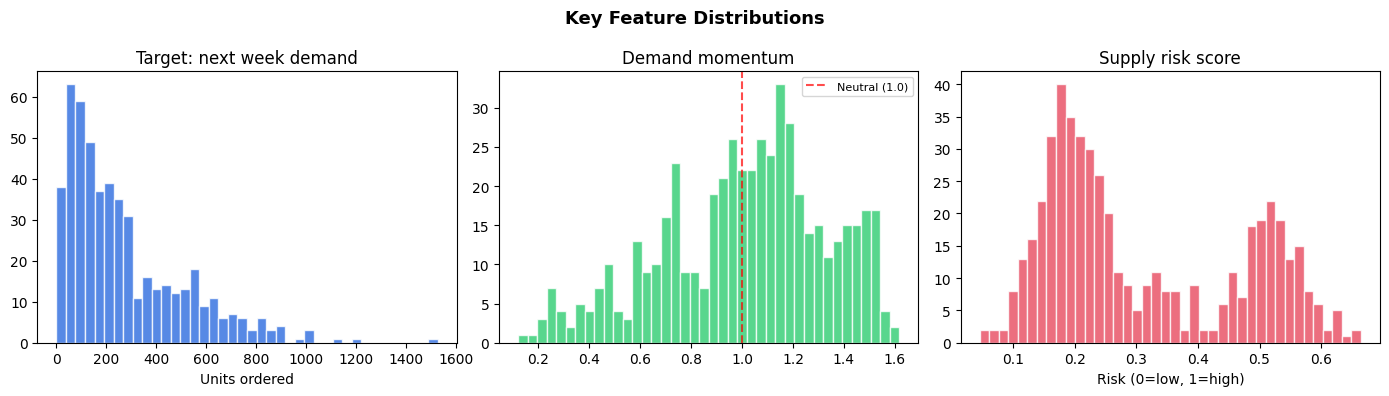

In [9]:

# ── Quick distribution check ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Key Feature Distributions", fontsize=13, fontweight='bold')

# Target variable distribution
axes[0].hist(df['target_next_week_demand'], bins=40, color='#2d6cdf', edgecolor='white', alpha=0.8)
axes[0].set_title('Target: next week demand')
axes[0].set_xlabel('Units ordered')

# Demand momentum (should be centered ~1.0)
axes[1].hist(df['demand_momentum'], bins=40, color='#2ecc71', edgecolor='white', alpha=0.8)
axes[1].axvline(1.0, color='red', ls='--', alpha=0.7, label='Neutral (1.0)')
axes[1].set_title('Demand momentum')
axes[1].legend(fontsize=8)

# Supply risk score (should be 0-1)
axes[2].hist(df['supply_risk_score'], bins=40, color='#e84a5f', edgecolor='white', alpha=0.8)
axes[2].set_title('Supply risk score')
axes[2].set_xlabel('Risk (0=low, 1=high)')

plt.tight_layout()
plt.savefig('data/processed/feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()


In [10]:

# ── Save the ML-ready dataset ─────────────────────────────────────────────────
output_path = f"{PROCESSED_DIR}/ml_dataset.csv"
df.to_csv(output_path, index=False)

size_kb = os.path.getsize(output_path) / 1024
print(f"💾 Saved: {output_path}")
print(f"   Shape:   {df.shape[0]} rows × {df.shape[1]} columns")
print(f"   Size:    {size_kb:.1f} KB")
print(f"   Target:  target_next_week_demand")
print(f"   Features: {df.shape[1] - 1}")

# ── Save feature list separately (useful for model training notebook) ─────────
feature_cols = [c for c in df.columns if c != 'target_next_week_demand']
import json
with open(f"{PROCESSED_DIR}/feature_list.json", 'w') as f:
    json.dump({'features': feature_cols, 'target': 'target_next_week_demand'}, f, indent=2)
print(f"\n💾 Feature list saved to data/processed/feature_list.json")


💾 Saved: data/processed/ml_dataset.csv
   Shape:   510 rows × 71 columns
   Size:    238.4 KB
   Target:  target_next_week_demand
   Features: 70

💾 Feature list saved to data/processed/feature_list.json



<div style="background:linear-gradient(135deg,#1a2a4a 0%,#2d4a7a 100%);padding:30px 35px;border-radius:12px;margin-top:30px;">
  <h2 style="color:white;margin-top:0;">✅ Step 2 complete — What we built</h2>
  <div style="display:grid;grid-template-columns:1fr 1fr 1fr;gap:20px;margin-top:20px;">
    <div style="background:rgba(255,255,255,0.1);padding:15px;border-radius:8px;">
      <div style="color:#a8c4e0;font-size:.85em;margin-bottom:5px;">DATASET</div>
      <div style="color:white;font-size:1.4em;font-weight:bold;">1 flat table</div>
      <div style="color:#a8c4e0;font-size:.8em;">~500 rows × 35+ features<br>all numeric · no nulls</div>
    </div>
    <div style="background:rgba(255,255,255,0.1);padding:15px;border-radius:8px;">
      <div style="color:#a8c4e0;font-size:.85em;margin-bottom:5px;">FEATURE TYPES</div>
      <div style="color:white;font-size:1.4em;font-weight:bold;">6 groups</div>
      <div style="color:#a8c4e0;font-size:.8em;">lags · rolling · calendar<br>external · derived · static</div>
    </div>
    <div style="background:rgba(255,255,255,0.1);padding:15px;border-radius:8px;">
      <div style="color:#a8c4e0;font-size:.85em;margin-bottom:5px;">NEXT STEP</div>
      <div style="color:white;font-size:1.4em;font-weight:bold;">Notebook 03</div>
      <div style="color:#a8c4e0;font-size:.8em;">XGBoost training<br>Walk-forward validation · SHAP</div>
    </div>
  </div>
  <p style="color:#a8c4e0;margin-top:20px;font-size:.9em;">📁 Dataset saved to <code style="background:rgba(255,255,255,0.15);padding:2px 6px;border-radius:4px;">data/processed/ml_dataset.csv</code></p>
</div>
